# CBIM Problem Canvas — Retail Sales Pulse

### Situation (S)
   * According to the the provided  Documents. the retail chain has 6 months of historical sales data in a CSV file and receives weekly sales data through an API response. The data contains sales information such as store, city, category, units sold, and revenue. Currently, these data sources need to be analyzed to understand store performance, category trends, and weekly changes.

### Complication (C)

* The operations head cannot quickly identify which stores or categories are underperforming, unusual revenue drops, or important changes in weekly sales. Manual analysis also makes it difficult to compare the latest weekly performance with historical performance and take timely action. Finding null values, negative values, duplicates.  

### Question (Q)

* Which stores and product categories need attention, and what actions should the operations head take based on historical and current weekly sales data? The analysis should identify performance trends, anomalies, and category alerts, while the automation should generate a clear weekly sales summary for decision-making.

### SSOT

* Part 1: The historical CSV dataset is the source of truth for six-month historical analysis. Part 2: The weekly API response (JSON) is the source of truth for the latest week's sales. The weekly API data represents the most recent sales period and can be compared with the historical CSV data to identify unusual changes and alerts.

### Success Definition

* Part 1: Successfully identify important business insights such as the highest/lowest performing stores, category trends, weekday patterns, and revenue anomalies. Part 2: Successfully process the weekly API response and generate a weekly sales summary with top store, bottom store, category revenue, and pipeline status.

### Primary Stakeholder

* Operations Head / Retail Management. They need to decide where to investigate performance problems, which categories need attention, and where to focus promotions or operational improvements. These decisions should be made weekly, using the latest sales data.

# PART 1 — Retail Sales Pulse: Exploratory Data Analysis

## 5.1  Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

In [3]:
df.shape

(107836, 10)

In [4]:
df.head(10)

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0
5,TXN000006,2026-01-01,S01,Vijayawada,Apparel,Formal Shirt,2,936.28,1498.05,20
6,TXN000007,2026-01-01,S01,Vijayawada,Apparel,T-Shirt,2,1005.41,1910.28,5
7,TXN000008,2026-01-01,S01,Vijayawada,Apparel,Kurta,3,2728.18,8184.54,0
8,TXN000009,2026-01-01,S01,Vijayawada,Apparel,T-Shirt,2,1388.80,2777.60,0
9,TXN000010,2026-01-01,S01,Vijayawada,Apparel,Jeans,2,3363.08,6053.54,10


In [5]:
df.tail(10)

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
107826,TXN107827,2026-06-30,S12,Kakinada,Grocery,Atta (5kg),1,177.83,151.16,15
107827,TXN107828,2026-06-30,S12,Kakinada,Grocery,Dal (1kg),3,571.87,1715.61,0
107828,TXN107829,2026-06-30,S12,Kakinada,Grocery,Oil (1L),4,447.56,1611.22,10
107829,TXN107830,2026-06-30,S12,Kakinada,Home & Kitchen,Storage Box,4,7107.53,28430.12,0
107830,TXN107831,2026-06-30,S12,Kakinada,Personal Care,Toothpaste,4,840.01,3360.04,0
107831,TXN107832,2026-06-30,S12,Kakinada,Personal Care,Shampoo,4,803.64,3214.56,0
107832,TXN107833,2026-06-30,S12,Kakinada,Personal Care,Body Lotion,2,288.41,547.98,5
107833,TXN107834,2026-06-30,S12,Kakinada,Personal Care,Shampoo,2,808.72,1536.57,5
107834,TXN107835,2026-06-30,S12,Kakinada,Personal Care,Face Wash,5,237.13,1185.65,0
107835,TXN107836,2026-06-30,S12,Kakinada,Personal Care,Face Wash,1,921.75,783.49,15


In [6]:
df.columns

Index(['transaction_id', 'date', 'store_id', 'store_city', 'category',
       'product_name', 'units_sold', 'unit_price', 'revenue', 'discount_pct'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  object 
 1   date            107836 non-null  object 
 2   store_id        107836 non-null  object 
 3   store_city      107836 non-null  object 
 4   category        107836 non-null  object 
 5   product_name    107836 non-null  object 
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 8.2+ MB


In [8]:
df.isnull().sum()

transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,units_sold,unit_price,revenue,discount_pct
count,107836.000000,107836.000000,107836.000000,107836.000000
mean,2.583488,1778.097787,4263.920924,7.228152
std,1.471616,5053.631792,14243.244169,6.730445
min,1.000000,50.020000,40.040000,0.000000
25%,1.000000,274.827500,467.772500,0.000000
50%,2.000000,488.450000,1034.615000,5.000000
75%,3.000000,1039.522500,2473.335000,10.000000
max,13.000000,44990.140000,355090.880000,20.000000


In [11]:
count=df['product_name'].value_counts()
count

product_name
Rice (5kg)         10971
Sugar (1kg)        10831
Dal (1kg)          10803
Atta (5kg)         10795
Oil (1L)           10785
Shampoo             5276
Body Lotion         5271
Toothpaste          5178
Face Wash           5173
Sunscreen           5049
T-Shirt             3123
Formal Shirt        3082
Saree               3078
Kurta               3033
Jeans               2985
Mixer Grinder       1715
Storage Box         1699
Water Bottle        1675
Dinner Set          1667
Pressure Cooker     1632
Laptop               837
Tablet               820
Mobile Phone         796
Headphones           790
Smart TV             772
Name: count, dtype: int64

In [12]:
city=df['store_city'].value_counts()
city

store_city
Vijayawada     23083
Guntur         21742
Tirupati       19949
Rajahmundry    16478
Nellore        13883
Kakinada       12701
Name: count, dtype: int64

In [13]:
category=df['category'].value_counts()
category

category
Grocery           54185
Personal Care     25947
Apparel           15301
Home & Kitchen     8388
Electronics        4015
Name: count, dtype: int64

In [14]:
df.select_dtypes(include='number').lt(0).sum().sum()

np.int64(0)

In [15]:
df.select_dtypes(include='float').lt(0).sum().sum()

np.int64(0)

### No null values , NO dupliactes , No invalid data, No negative values.The dataset was clean.

#### Observation 1
- The average transaction value is much lower than the maximum transaction value, which suggests that most purchases are relatively small, while a few very high-value transactions may have a strong impact on total revenue. These high-value transactions should be monitored to understand which products or customer purchases drive them.

#### Observation 2
- The average number of units sold per transaction is low, suggesting that customers generally purchase only a small number of items per transaction. The business could explore product bundles, cross-selling, or promotional offers to increase the number of items purchased per transaction.

## 5.2 Revenue by store

In [16]:
store_revenue = (
    df.groupby(["store_id", "store_city"])["revenue"].sum()
      .reset_index()
      .sort_values("revenue", ascending=False)
)
store_revenue

,store_id,store_city,revenue
0,S01,Vijayawada,59055493.38
2,S03,Guntur,53175162.00
6,S07,Tirupati,48537659.56
5,S06,Rajahmundry,44969840.50
1,S02,Vijayawada,42069856.33
3,S04,Guntur,41379797.16
7,S08,Tirupati,35032561.12
8,S09,Nellore,33452441.09
10,S11,Kakinada,32780138.71
4,S05,Rajahmundry,25157347.02


In [ ]:
store_revenue = (
    df.groupby(["store_id", "store_city"])["revenue"]
      .sum()
      .reset_index()
      .sort_values("revenue", ascending=False)
)


store_revenue["revenue_crore"] = store_revenue["revenue"] / 10_000_000

print("Revenue by Store:")
display(store_revenue)

Revenue by Store:


,store_id,store_city,revenue,revenue_crore
0,S01,Vijayawada,59055493.38,5.905549
2,S03,Guntur,53175162.00,5.317516
6,S07,Tirupati,48537659.56,4.853766
5,S06,Rajahmundry,44969840.50,4.496984
1,S02,Vijayawada,42069856.33,4.206986
3,S04,Guntur,41379797.16,4.137980
7,S08,Tirupati,35032561.12,3.503256
8,S09,Nellore,33452441.09,3.345244
10,S11,Kakinada,32780138.71,3.278014
4,S05,Rajahmundry,25157347.02,2.515735


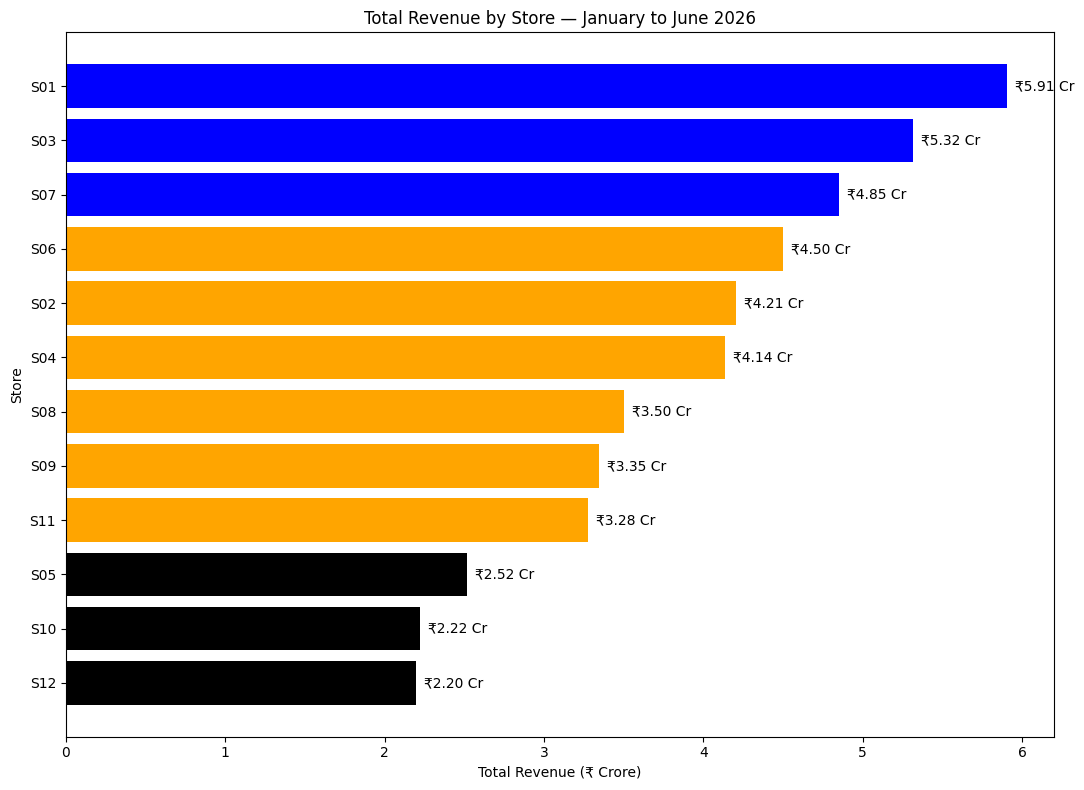

In [18]:
plot_data = store_revenue.sort_values("revenue_crore", ascending=True)

bar_colors = []

for store in plot_data["store_id"]:
    if store in ["S01", "S03", "S07"]:
        bar_colors.append("blue")
    elif store in ["S05", "S10", "S12"]:
        bar_colors.append("black")
    else:
        bar_colors.append("orange")

plt.figure(figsize=(11, 8))

bars = plt.barh(
    plot_data["store_id"],
    plot_data["revenue_crore"],
    color=bar_colors
)

plt.xlabel("Total Revenue (₹ Crore)")
plt.ylabel("Store")
plt.title("Total Revenue by Store — January to June 2026")

for bar, value in zip(bars, plot_data["revenue_crore"]):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"₹{value:.2f} Cr",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Observation 1: 
- S01 in Vijayawada has the highest sales, while S12 in Kakinada has the lowest. This may be due to differences in customer demand, stock, pricing, or promotions.

#### Observation 2: 
- The big difference between stores shows that the team should find out why some stores perform better than others and improve the weaker stores.

#### key question: 
- What can be done to improve the performance of low-performing stores?

## 5.3 Category performance over time

In [19]:
df["date"] = pd.to_datetime(df["date"])

In [20]:
df["month"] = df["date"].dt.to_period("M").astype(str)

In [21]:
category_monthly = (
    df.groupby(["month", "category"])["revenue"]
      .sum()
      .reset_index()
)
category_monthly

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81
5,2026-02,Apparel,9510938.10
6,2026-02,Electronics,38988602.50
7,2026-02,Grocery,6534957.35
8,2026-02,Home & Kitchen,13006413.31
9,2026-02,Personal Care,5792754.97


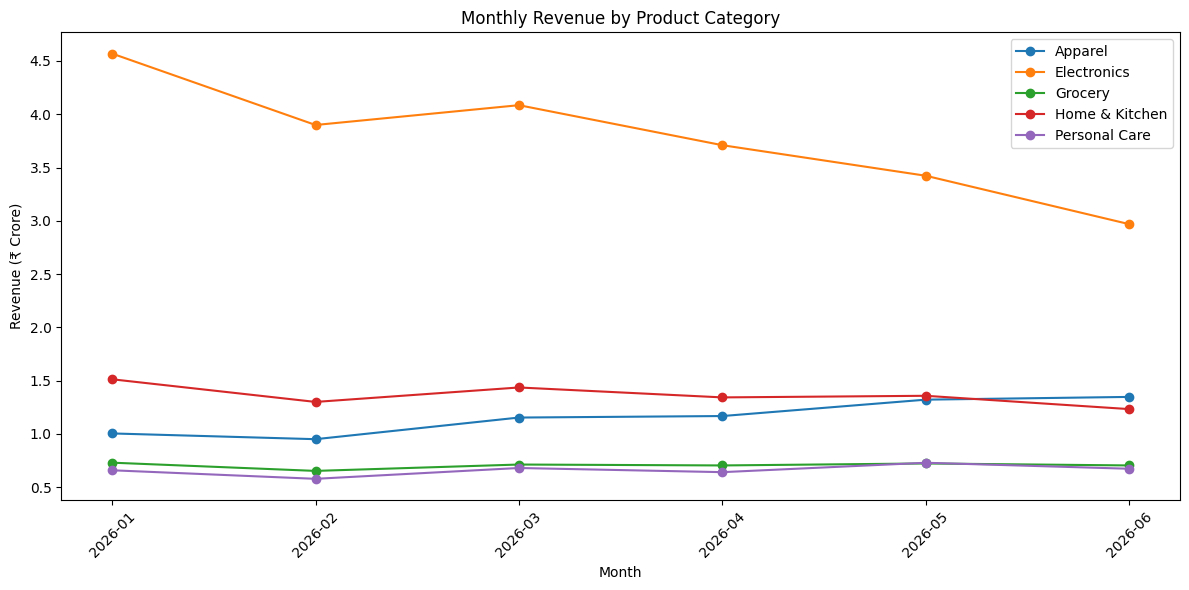

In [22]:
plt.figure(figsize=(12, 6))

for category in category_monthly["category"].unique():

    category_data = category_monthly[
        category_monthly["category"] == category
    ]

    plt.plot(
        category_data["month"],
        category_data["revenue"] / 10_000_000,
        marker="o",
        label=category
    )

plt.xlabel("Month")
plt.ylabel("Revenue (₹ Crore)")
plt.title("Monthly Revenue by Product Category")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### What might this mean for the business?
- This could indicate falling customer demand, reduced promotional effectiveness, pricing changes, or inventory/availability problems. Since Electronics is an important revenue-generating category, continued decline could negatively affect overall sales.

#### Question it raises:

-  Why are Electronics sales declining — is it because of lower customer demand, pricing, reduced promotions, or stock availability?

## 5.4 Day-of-week and monthly patterns

In [23]:
df["day"] = df["date"].dt.day_name()

In [24]:
daily_revenue = (df.groupby("date")["revenue"].sum().reset_index())
daily_revenue

,date,revenue
0,2026-01-01,1811086.82
1,2026-01-02,2846032.80
2,2026-01-03,4214219.34
3,2026-01-04,3122804.05
4,2026-01-05,1935902.72
...,...,...
176,2026-06-26,2132585.36
177,2026-06-27,3337874.15
178,2026-06-28,2411911.36
179,2026-06-29,1633487.33


In [25]:
daily_revenue["day"] = daily_revenue["date"].dt.day_name()
daily_revenue

,date,revenue,day
0,2026-01-01,1811086.82,Thursday
1,2026-01-02,2846032.80,Friday
2,2026-01-03,4214219.34,Saturday
3,2026-01-04,3122804.05,Sunday
4,2026-01-05,1935902.72,Monday
...,...,...,...
176,2026-06-26,2132585.36,Friday
177,2026-06-27,3337874.15,Saturday
178,2026-06-28,2411911.36,Sunday
179,2026-06-29,1633487.33,Monday


In [26]:
weekday_revenue = (
    daily_revenue.groupby("day")["revenue"].mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)
weekday_revenue

day
Monday       2.012141e+06
Tuesday      2.054130e+06
Wednesday    2.228117e+06
Thursday     2.245493e+06
Friday       2.623612e+06
Saturday     3.523605e+06
Sunday       3.083375e+06
Name: revenue, dtype: float64

In [27]:
monthly_revenue = (
    df.groupby("month")["revenue"].sum()
)
monthly_revenue

month
2026-01    84768131.10
2026-02    73833666.23
2026-03    80689884.84
2026-04    75670487.12
2026-05    75559873.38
2026-06    69282134.11
Name: revenue, dtype: float64

In [28]:
best_day = weekday_revenue.idxmax()
best_day_value = weekday_revenue.max()

worst_day = weekday_revenue.idxmin()
worst_day_value = weekday_revenue.min()

print("Best day:", best_day)
print("Average revenue:", best_day_value)

print("Worst day:", worst_day)
print("Average revenue:", worst_day_value)

Best day: Saturday
Average revenue: 3523605.445
Worst day: Monday
Average revenue: 2012140.9634615383


In [29]:
best_month = monthly_revenue.idxmax()
best_month_value = monthly_revenue.max()

worst_month = monthly_revenue.idxmin()
worst_month_value = monthly_revenue.min()

print("Best month:", best_month)
print("Revenue:", best_month_value)

print("Worst month:", worst_month)
print("Revenue:", worst_month_value)

Best month: 2026-01
Revenue: 84768131.1
Worst month: 2026-06
Revenue: 69282134.11


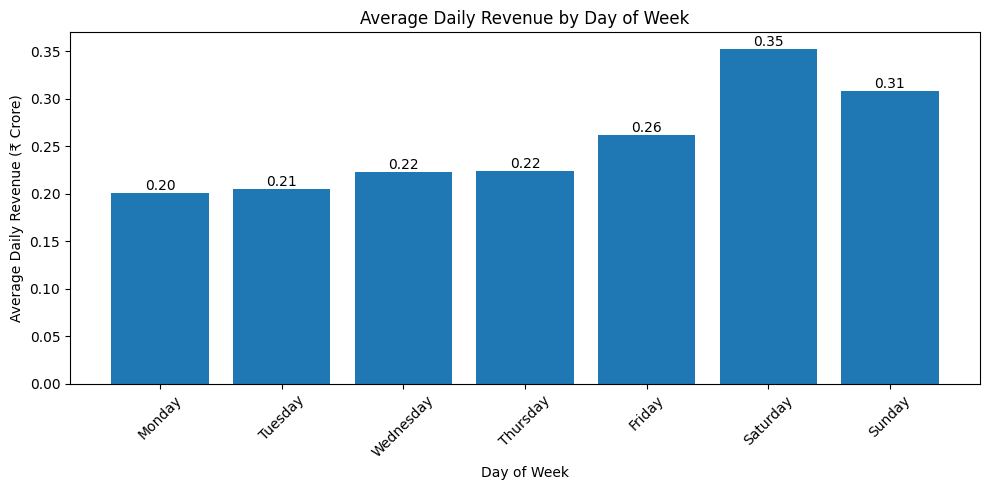

In [30]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    weekday_revenue.index,
    weekday_revenue.values / 10000000
)
plt.bar_label(bars, fmt="%.2f")

plt.xlabel("Day of Week")
plt.ylabel("Average Daily Revenue (₹ Crore)")
plt.title("Average Daily Revenue by Day of Week")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

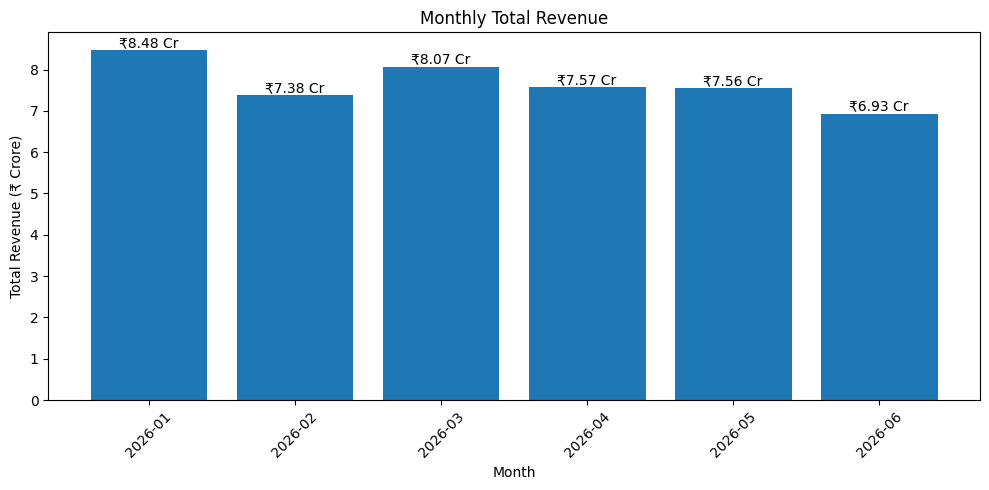

In [31]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    monthly_revenue.index,
    monthly_revenue.values / 10000000
)
labels = [f"₹{x:.2f} Cr" for x in monthly_revenue.values / 10000000]

plt.bar_label(bars, labels=labels)

plt.xlabel("Month")
plt.ylabel("Total Revenue (₹ Crore)")
plt.title("Monthly Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.5 Anomaly identification

In [32]:
df["date"] = pd.to_datetime(df["date"])

In [33]:
df["week"] = df["date"] - pd.to_timedelta(df["date"].dt.weekday, unit="D")

In [34]:
complete_weeks = df.groupby("week")["date"].nunique()
complete_weeks = complete_weeks[complete_weeks == 7].index
df_complete = df[df["week"].isin(complete_weeks)]

In [35]:
weekly_revenue = df_complete.groupby(["store_id", "store_city", "week"])["revenue"].sum().reset_index()
weekly_revenue

,store_id,store_city,week,revenue
0,S01,Vijayawada,2026-01-05,2350618.81
1,S01,Vijayawada,2026-01-12,2316840.47
2,S01,Vijayawada,2026-01-19,2579278.37
3,S01,Vijayawada,2026-01-26,2000527.75
4,S01,Vijayawada,2026-02-02,2178007.52
...,...,...,...,...
295,S12,Kakinada,2026-05-25,773458.93
296,S12,Kakinada,2026-06-01,1068246.16
297,S12,Kakinada,2026-06-08,963850.07
298,S12,Kakinada,2026-06-15,1023998.72


In [36]:
store_stats = weekly_revenue.groupby("store_id")["revenue"].agg(["mean", "std"]).reset_index()
store_stats

,store_id,mean,std
0,S01,2.302970e+06,293995.108575
1,S02,1.627619e+06,226809.226710
2,S03,2.049074e+06,269100.872352
3,S04,1.598816e+06,228635.581011
4,S05,9.774069e+05,127113.547805
5,S06,1.741919e+06,267725.531989
6,S07,1.876781e+06,308258.987633
7,S08,1.334241e+06,177407.496556
8,S09,1.290915e+06,169966.407685
9,S10,8.671293e+05,163809.391223


In [37]:
store_stats["lower_limit"] = (store_stats["mean"] - 2 * store_stats["std"])

In [38]:
weekly_revenue = weekly_revenue.merge(store_stats,on="store_id")

In [39]:
weekly_revenue["anomaly"] = (weekly_revenue["revenue"] <weekly_revenue["lower_limit"])

In [40]:
anomalies = weekly_revenue[
    weekly_revenue["anomaly"] == True
]
anomalies

,store_id,store_city,week,revenue,mean,std,lower_limit,anomaly
44,S02,Vijayawada,2026-05-18,1173289.36,1.627619e+06,226809.226710,1.174000e+06,True
97,S04,Guntur,2026-06-08,1137480.32,1.598816e+06,228635.581011,1.141545e+06,True
105,S05,Rajahmundry,2026-02-09,655732.19,9.774069e+05,127113.547805,7.231798e+05,True
238,S10,Nellore,2026-04-06,505536.54,8.671293e+05,163809.391223,5.395105e+05,True


### Possible Business Reasons for Revenue Anomalies

* Supply disruption — Some important products may have been out of stock, which could have reduced sales during the week.

* Local event — A local festival, event, or temporary disruption may have reduced customer footfall.

* Pricing issue — Prices may have been less competitive than usual, causing customers to buy less.

* Competitor activity — A nearby competitor may have offered discounts or promotions, attracting customers away.


## 5.6 — Business Recommendation

- S01 – Vijayawada generated the highest six-month revenue: ₹5.91 crore. 
- S12 – Kakinada generated the lowest six-month revenue: ₹2.20 crore(Investigate Needed). 
- January recorded the highest monthly revenue: ₹8.48 crore. 
- Saturday had the highest average daily revenue: ₹35.24 lakh. 
- Electronics revenue declined by ~25% from January to June, which needs attention. 
- Anomalies were identified in S05, S10, S02, and S04, indicating unusually low weekly revenue compared with their normal performance. 
- Recommended action: Investigate the anomalous store-weeks, especially S10 – Nellore, and check for inventory, demand, pricing, or operational issues. 


* Management should prioritize low-performing stores, anomalous weeks, and the declining Electronics category, while using the strong weekend demand and successful store practices to improve overall revenue.




# PART 2 — Automating the Pulse: Data Pipeline & Validation

## 5.7  Understand the JSON structure

In [41]:
import numpy as np
import pandas as pd
import json 

In [42]:
with open("MUC01_Weekly_Sales_API_Response.json", "r") as f:
    data = json.load(f)

In [43]:
print(data.keys())

dict_keys(['status', 'request_id', 'generated_at', 'period', 'record_count', 'data'])


In [44]:
print(type(data["data"]))
print(len(data["data"]))

<class 'list'>
4291


In [45]:
data["data"][300]

{'transaction_id': 'TXN103846',
 'date': '2026-06-24',
 'store_id': 'S06',
 'store_city': 'Rajahmundry',
 'category': 'Grocery',
 'product_name': 'Sugar (1kg)',
 'units_sold': 1,
 'unit_price': 201.73,
 'revenue': 181.56,
 'discount_pct': 10}

### Understand the JSON Structure

- The JSON has six top-level keys: `status`, `request_id`, `generated_at`, `period`, `record_count`, and `data`. The `data` key contains the actual transaction records.

- The actual transaction data sits inside the data key of the JSON. The data key contains a list of 4,291 transaction records, with each record representing a sales transaction.


## 5.8 Ingest and parse the API response

In [46]:
transactions = data["data"]
weekly_df = pd.DataFrame(transactions)
weekly_df.head(10)

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN103546,2026-06-24,S01,Vijayawada,Electronics,Headphones,3,13899.23,41697.69,0
1,TXN103547,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,2,1470.83,2941.66,0
2,TXN103548,2026-06-24,S01,Vijayawada,Apparel,Saree,4,2706.78,10827.12,0
3,TXN103549,2026-06-24,S01,Vijayawada,Apparel,Saree,3,3257.93,9773.79,0
4,TXN103550,2026-06-24,S01,Vijayawada,Apparel,Jeans,1,2118.31,2118.31,0
5,TXN103551,2026-06-24,S01,Vijayawada,Apparel,T-Shirt,3,556.42,1669.26,0
6,TXN103552,2026-06-24,S01,Vijayawada,Apparel,Saree,4,1860.52,6697.87,10
7,TXN103553,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,5,1789.13,8945.65,0
8,TXN103554,2026-06-24,S01,Vijayawada,Apparel,Jeans,2,1545.24,2472.38,20
9,TXN103555,2026-06-24,S01,Vijayawada,Apparel,Kurta,2,1489.94,2383.90,20


In [47]:
weekly_df["date"] = pd.to_datetime(weekly_df["date"])

In [48]:
print("Records in DataFrame:", len(weekly_df))
print("Records in JSON:", data["record_count"])

Records in DataFrame: 4291
Records in JSON: 4291


In [49]:
print(data["period"])

{'from': '2026-06-24', 'to': '2026-06-30'}


In [50]:
weekly_df.head(5)

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN103546,2026-06-24,S01,Vijayawada,Electronics,Headphones,3,13899.23,41697.69,0
1,TXN103547,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,2,1470.83,2941.66,0
2,TXN103548,2026-06-24,S01,Vijayawada,Apparel,Saree,4,2706.78,10827.12,0
3,TXN103549,2026-06-24,S01,Vijayawada,Apparel,Saree,3,3257.93,9773.79,0
4,TXN103550,2026-06-24,S01,Vijayawada,Apparel,Jeans,1,2118.31,2118.31,0



**why would a production pipeline always check that the record count in the metadata matches the actual records received?**
- The record count is checked to ensure that all expected records were received. If the metadata count and actual record count do not match, it may indicate missing or incomplete data. This helps prevent incorrect analysis and business decisions based on incomplete data.

## 5.9 Validate the data before processing

In [51]:
with open("MUC01_Weekly_Sales_API_Corrupt.json", "r") as f:
    corrupt_data = json.load(f)

In [52]:
corrupt_df = pd.DataFrame(corrupt_data["data"])
corrupt_df.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN103546,2026-06-24,S01,Vijayawada,Electronics,Headphones,3.0,13899.23,41697.69,0
1,TXN103547,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,2.0,1470.83,2941.66,0
2,TXN103548,2026-06-24,S01,Vijayawada,Apparel,Saree,4.0,2706.78,10827.12,0
3,TXN103549,2026-06-24,S01,Vijayawada,Apparel,Saree,3.0,3257.93,9773.79,0
4,TXN103550,2026-06-24,S01,Vijayawada,Apparel,Jeans,1.0,2118.31,2118.31,0


In [53]:
corrupt_df["date"] = pd.to_datetime(corrupt_df["date"])

In [54]:
len(corrupt_df)

4291

In [55]:
corrupt_df.shape

(4291, 10)

In [56]:
corrupt_df.isnull().sum()

transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        1
unit_price        0
revenue           0
discount_pct      0
dtype: int64

In [57]:
corrupt_df.duplicated().sum()

np.int64(0)

In [58]:
print((corrupt_df["revenue"] <= 0).sum())

1


In [59]:
print(corrupt_df[corrupt_df["revenue"] <= 0])

  transaction_id       date store_id  store_city category product_name  \
5      TXN103551 2026-06-24      S01  Vijayawada  Apparel      T-Shirt   

   units_sold  unit_price  revenue  discount_pct  
5         3.0      556.42   -150.0             0  


In [60]:
corrupt_df["store_id"].value_counts()

store_id
S01    528
S03    471
S07    434
S06    429
S02    403
S04    382
S08    345
S09    317
S11    308
S05    248
S10    228
S12    197
S99      1
Name: count, dtype: int64

In [61]:
corrupt_df["product_name"].value_counts()

product_name
Sugar (1kg)        457
Oil (1L)           429
Dal (1kg)          419
Atta (5kg)         410
Rice (5kg)         401
Shampoo            244
Sunscreen          229
Toothpaste         212
Body Lotion        186
Face Wash          183
Formal Shirt       166
T-Shirt            147
Kurta              137
Jeans              127
Saree              125
Mixer Grinder       79
Storage Box         67
Water Bottle        59
Pressure Cooker     53
Dinner Set          43
Laptop              29
Smart TV            29
Headphones          26
Tablet              20
Mobile Phone        14
Name: count, dtype: int64

In [62]:
print(corrupt_df.groupby(["store_id", "store_city"]).size())

store_id  store_city 
S01       Vijayawada     528
S02       Vijayawada     403
S03       Guntur         471
S04       Guntur         382
S05       Rajahmundry    248
S06       Rajahmundry    429
S07       Tirupati       434
S08       Tirupati       345
S09       Nellore        317
S10       Nellore        228
S11       Kakinada       308
S12       Kakinada       197
S99       Vijayawada       1
dtype: int64


In [63]:
print(corrupt_df[corrupt_df["store_id"] == "S99"]["product_name"])

20    Atta (5kg)
Name: product_name, dtype: object


In [64]:
print((~corrupt_df["store_id"].isin([f"S{i:02d}" for i in range(1, 13)])).sum())

1


In [69]:
print("Validation Summary")
print("------------------")

print("Total records checked:", len(corrupt_df))

# Null values
null_rows = corrupt_df[corrupt_df["units_sold"].isnull()]
print("Null values found:", len(null_rows),
      "(row", null_rows.index[0] + 1, ", column: units_sold)")

# Negative revenue
negative_rows = corrupt_df[corrupt_df["revenue"] <= 0]
print("Negative revenue found:", len(negative_rows),
      "(row", negative_rows.index[0] + 1,
      ", revenue:", negative_rows["revenue"].iloc[0], ")")

# Invalid store ID
invalid_rows = corrupt_df[
    ~corrupt_df["store_id"].isin([f"S{i:02d}" for i in range(1, 13)])
]
print("Invalid store IDs found:", len(invalid_rows),
      "(row", invalid_rows.index[0] + 1,
      ", store_id:", invalid_rows["store_id"].iloc[0], ")")

# Status
total_issues = len(null_rows) + len(negative_rows) + len(invalid_rows)

if total_issues > 0:
    print("Status: FAILED —", total_issues, "issues detected. Pipeline halted.")
else:
    print("Status: PASSED — No issues detected.")

Validation Summary
------------------
Total records checked: 4291
Null values found: 1 (row 13 , column: units_sold)
Negative revenue found: 1 (row 6 , revenue: -150.0 )
Invalid store IDs found: 1 (row 21 , store_id: S99 )
Status: FAILED — 3 issues detected. Pipeline halted.


In [86]:
total_issues = len(null_rows) + len(negative_rows) + len(invalid_rows)
total_issues

3

* A well-designed pipeline should **stop completely when critical corrupt data is found**, because processing invalid data can lead to incorrect results and unreliable business decisions.


## 5.10 Transform and aggregate

I used cleaned "MUC01_Weekly_Sales_API_Response.json"

In [70]:
weekly_revenue_by_store = weekly_df.groupby(["store_id", "store_city"])["revenue"].sum().reset_index()
weekly_revenue_by_store

,store_id,store_city,revenue
0,S01,Vijayawada,1608043.08
1,S02,Vijayawada,1218330.60
2,S03,Guntur,2037560.19
3,S04,Guntur,1285265.18
4,S05,Rajahmundry,941961.76
5,S06,Rajahmundry,1565006.35
6,S07,Tirupati,1349795.33
7,S08,Tirupati,1269260.54
8,S09,Nellore,976322.30
9,S10,Nellore,627119.87


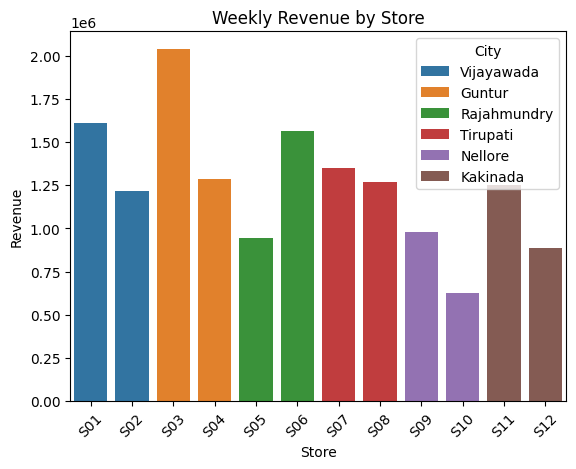

In [71]:
sns.barplot(
    data=weekly_revenue_by_store,
    x="store_id",
    y="revenue",
    hue="store_city"
)

plt.title("Weekly Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="City")
plt.show()

In [72]:
weekly_revenue_by_category = weekly_df.groupby("category")["revenue"].sum().reset_index()

print(weekly_revenue_by_category)

         category     revenue
0         Apparel  3228573.10
1     Electronics  5764693.85
2         Grocery  1617278.70
3  Home & Kitchen  2847057.00
4   Personal Care  1557807.63


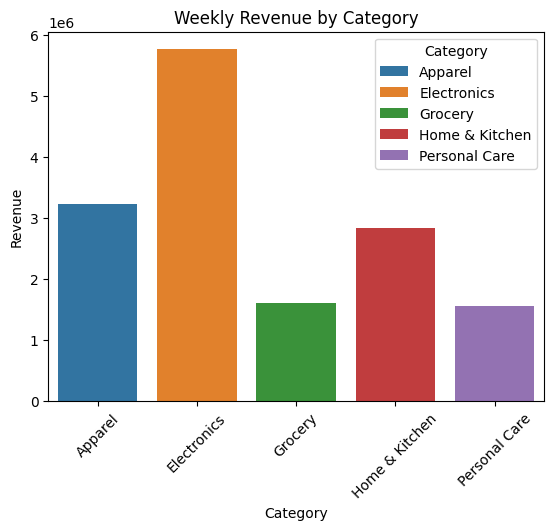

In [73]:
sns.barplot(
    data=weekly_revenue_by_category,
    x="category",
    y="revenue",
    hue="category",
    legend=True
)

plt.title("Weekly Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.show()

In [74]:
top_store = weekly_revenue_by_store.sort_values("revenue", ascending=False)
top_store

,store_id,store_city,revenue
2,S03,Guntur,2037560.19
0,S01,Vijayawada,1608043.08
5,S06,Rajahmundry,1565006.35
6,S07,Tirupati,1349795.33
3,S04,Guntur,1285265.18
7,S08,Tirupati,1269260.54
10,S11,Kakinada,1249928.27
1,S02,Vijayawada,1218330.60
8,S09,Nellore,976322.30
4,S05,Rajahmundry,941961.76


##### category_alert on "MUC01_Retail_Sales_Dataset.csv"

In [75]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0
...,...,...,...,...,...,...,...,...,...,...
107831,TXN107832,2026-06-30,S12,Kakinada,Personal Care,Shampoo,4,803.64,3214.56,0
107832,TXN107833,2026-06-30,S12,Kakinada,Personal Care,Body Lotion,2,288.41,547.98,5
107833,TXN107834,2026-06-30,S12,Kakinada,Personal Care,Shampoo,2,808.72,1536.57,5
107834,TXN107835,2026-06-30,S12,Kakinada,Personal Care,Face Wash,5,237.13,1185.65,0


#### Date & Category

In [76]:
daily_category = df.groupby(["date", "category"])["revenue"].sum().reset_index()
daily_category

,date,category,revenue
0,2026-01-01,Apparel,270826.24
1,2026-01-01,Electronics,714896.88
2,2026-01-01,Grocery,206080.47
3,2026-01-01,Home & Kitchen,422346.76
4,2026-01-01,Personal Care,196936.47
...,...,...,...
900,2026-06-30,Apparel,355716.23
901,2026-06-30,Electronics,558287.56
902,2026-06-30,Grocery,198505.40
903,2026-06-30,Home & Kitchen,265182.00


#### category_average

In [77]:
category_average = daily_category.groupby("category")["revenue"].mean().reset_index()
category_average

,category,revenue
0,Apparel,3.838651e+05
1,Electronics,1.251534e+06
2,Grocery,2.337159e+05
3,Home & Kitchen,4.521863e+05
4,Personal Care,2.190528e+05


In [78]:
category_average.columns = ["category", "daily_average"]

In [79]:
category_average["weekly_average"] = category_average["daily_average"] * 7

In [80]:
category_alert = weekly_revenue_by_category.merge(category_average, on="category")
category_alert = category_alert[
    category_alert["revenue"] < category_alert["weekly_average"] * 0.8
]
category_alert

,category,revenue,daily_average,weekly_average
1,Electronics,5764693.85,1.251534e+06,8.760741e+06


- It means Electronics revenue this week is more than 20% below its normal 6-month weekly average.

## 5.11 Pipeline summary output

In [81]:
store_revenue = weekly_df.groupby(
    ["store_id", "store_city"]
)["revenue"].sum().reset_index()

print(store_revenue)

   store_id   store_city     revenue
0       S01   Vijayawada  1608043.08
1       S02   Vijayawada  1218330.60
2       S03       Guntur  2037560.19
3       S04       Guntur  1285265.18
4       S05  Rajahmundry   941961.76
5       S06  Rajahmundry  1565006.35
6       S07     Tirupati  1349795.33
7       S08     Tirupati  1269260.54
8       S09      Nellore   976322.30
9       S10      Nellore   627119.87
10      S11     Kakinada  1249928.27
11      S12     Kakinada   886816.81


In [82]:
top_store = store_revenue.sort_values("revenue", ascending=False).iloc[0]
print(top_store)

store_id             S03
store_city        Guntur
revenue       2037560.19
Name: 2, dtype: object


In [83]:
bottom_store = store_revenue.sort_values("revenue", ascending=True).iloc[0]
print(bottom_store)

store_id            S10
store_city      Nellore
revenue       627119.87
Name: 9, dtype: object


In [84]:
category_revenue = weekly_df.groupby("category")["revenue"].sum().reset_index()
print(category_revenue)

         category     revenue
0         Apparel  3228573.10
1     Electronics  5764693.85
2         Grocery  1617278.70
3  Home & Kitchen  2847057.00
4   Personal Care  1557807.63


In [85]:
def generate_weekly_summary():

    with open("MUC01_Weekly_Sales_API_Response.json", "r") as f:
        data = json.load(f)

    weekly_df = pd.DataFrame(data["data"])
    weekly_df["date"] = pd.to_datetime(weekly_df["date"])

    store_revenue = weekly_df.groupby(
        ["store_id", "store_city"]
    )["revenue"].sum().reset_index()

    top_store = store_revenue.sort_values(
        "revenue", ascending=False
    ).iloc[0]

    bottom_store = store_revenue.sort_values(
        "revenue", ascending=True
    ).iloc[0]

    category_revenue = weekly_df.groupby(
        "category"
    )["revenue"].sum().reset_index()

    print("=== RETAIL SALES PULSE — WEEKLY SUMMARY ===")
    print("Period:", data["period"]["from"], "to", data["period"]["to"])
    print("Records processed:", data["record_count"])

    print("Top store:", top_store["store_id"], top_store["store_city"])
    print("Bottom store:", bottom_store["store_id"], bottom_store["store_city"])

    print("Category revenue:")
    print(category_revenue)

    print("Pipeline status: COMPLETED SUCCESSFULLY")
    
generate_weekly_summary()

=== RETAIL SALES PULSE — WEEKLY SUMMARY ===
Period: 2026-06-24 to 2026-06-30
Records processed: 4291
Top store: S03 Guntur
Bottom store: S10 Nellore
Category revenue:
         category     revenue
0         Apparel  3228573.10
1     Electronics  5764693.85
2         Grocery  1617278.70
3  Home & Kitchen  2847057.00
4   Personal Care  1557807.63
Pipeline status: COMPLETED SUCCESSFULLY


### Monday Morning Operations Summary

* **Weekly Revenue:** ₹1.50 crore
* **Top Store:** S03 – Guntur — ₹20.38 lakh
* **Bottom Store:** S10 – Nellore — ₹6.27 lakh
* **Top Category:** Electronics — ₹57.65 lakh
* **Lowest Category:** Personal Care — ₹15.58 lakh
* **Records Processed:** 4,291
* **Pipeline Status:** Completed Successfully

**Operations Focus:** Review the performance gap between the top and bottom stores and monitor the Electronics category, which generated the highest revenue this week.


### Head of Retail Operations needs two things 

- A clear picture of what the data says right now

-  A way to get this picture automatically every week

#### A clear picture of what the data says right now

-  The six-month CSV analysis shows that some stores and categories perform much better than others. S01 – Vijayawada generated the highest six-month revenue of ₹5.91 crore, while S12 – Kakinada generated the lowest at ₹2.20 crore. Electronics declined by about 25% from January to June, while Apparel showed a clear growth trend during the same period. The analysis also identified unusually low-performing store-weeks, which may require investigation before allocating promotional spending.

- Business implication: Use these historical results as evidence when planning Q3 promotional priorities, but collect October–December data before making final Q3 allocation decisions.

#### A way to get this picture automatically every week

- The weekly JSON API response can be processed automatically to generate a Retail Sales Pulse every Monday. The pipeline checks the API data before processing, including record count and data-quality validation. It then produces weekly revenue by store and category, identifies the top-performing store, and generates an alert when a category performs more than 20% below its historical six-month baseline. The corrupt JSON is used to test the validation process so that incorrect data does not continue through the pipeline.

- Business benefit: The Operations Head receives an updated weekly sales picture without waiting for the data team to manually repeat the analysis.